# Data Cleaning
This notebook cleans the Thames tidal data: it resolves NaN values, merges `.txt`/`.xlsx` files, and produces one tidy CSV per physical gauge installation.

**Key design choice — `idSite` as primary key.** Some of the 13 gauge folders contain data from *multiple* physical gauges (e.g. `09_Coryton` has Thameshaven, No5 Jetty, and Holehaven; `12_Margate` has Pile and Harbour). Rather than concatenating them blindly, each file is assigned an `idSite` based on its filename, which links to the `GAUGE_METADATA` lookup table holding location info (easting, northing, lat, lon, chart datum). The cleaned per-gauge CSVs hold only `idSite | SiteName | DateTime | Observed`; the metadata table is saved alongside as `00_gauge_metadata.csv` and joins back in on `idSite`.

## Imports & configuration

In [5]:
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)

# !! UPDATE to your actual path !!
BASE_DIR   = Path(r"C:/Users/alfat/Documents/STA_MSc/Term_3/tidal_analysis_and_prediction/2_Deliverables")
YEAR_START = 2004
YEAR_END   = 2024

GAUGE_FOLDERS = [
    "01_Richmond", "02_Chelsea", "03_LondonBridgeTowerPier",
    "04_Charlton", "05_NorthWoolwichSilvertown", "06_Erith",
    "07_Tilbury", "08_GravesendDenton", "09_Coryton",
    "10_Southend", "11_ShiveringSand", "12_Margate", "13_Walton",
]

# ----------------------------------------------------------------
# Column alias sets — all lowercase, all variants you might encounter.
# Only DateTime and Observed are read from the source files; idSite
# and SiteName are assigned from the filename via GAUGE_METADATA
# (see next cell), so any internal id/name columns are ignored.
# ----------------------------------------------------------------
COLUMN_ALIASES = {
    "DateTime": {
        "datetime", "datatime", "date_time", "date time",
        "date", "time", "timestamp", "date/time",
    },
    "Observed": {
        "observed", "obs", "water level", "water_level",
        "level", "sea level", "sea_level", "height",
        "water height", "water_height", "wl",
        "tide level", "tide_level", "tidelevel",
    },
}

REQUIRED    = {"DateTime", "Observed"}
OUTPUT_COLS = ["idSite", "SiteName", "DateTime", "Observed"]

## Gauge metadata & filename → idSite rules

This is the master record of every physical gauge installation across the 13 folders. `idSite` is the primary key linking every observation to its location info. Add new rows here if more gauges turn up.

Coordinates are OSGB36 (Easting/Northing) and WGS84 decimal degrees. Chart datum is metres below ODN. Source: PLA "Thames Tide Gauge National Grid References".

In [6]:
# Coords converted from the PLA table's degrees+decimal-minutes to decimal degrees.
# Note: Southend longitude in the PLA reference is printed as '00 43.43\'N' but is
# clearly meant to be E (it's east of Greenwich); treated as +0.7238° here.
GAUGE_METADATA = pd.DataFrame([
    # idSite                          GaugeFolder                       SiteName                          PLA   Easting Northing   Lat        Lon         CD(m belowODN)  Status
    {"idSite": "01_RICHMOND",            "GaugeFolder": "01_Richmond",                 "SiteName": "Richmond Lock",             "PLA_Chart": 304, "Easting": 516980, "Northing": 175100, "Latitude": 51.4630, "Longitude": -0.3175, "ChartDatum_m_below_ODN": 0.61, "Status": "active"},
    {"idSite": "02_CHELSEA",             "GaugeFolder": "02_Chelsea",                  "SiteName": "Chelsea Bridge",            "PLA_Chart": 315, "Easting": 528580, "Northing": 177740, "Latitude": 51.4840, "Longitude": -0.1497, "ChartDatum_m_below_ODN": 2.44, "Status": "active"},
    {"idSite": "03_LONDONBRIDGE",        "GaugeFolder": "03_LondonBridgeTowerPier",    "SiteName": "London Bridge (Tower Pier)", "PLA_Chart": 318, "Easting": 533410, "Northing": 180480, "Latitude": 51.5075, "Longitude": -0.0790, "ChartDatum_m_below_ODN": 3.20, "Status": "active"},
    {"idSite": "04_CHARLTON",            "GaugeFolder": "04_Charlton",                 "SiteName": "Charlton (Cory's)",         "PLA_Chart": 323, "Easting": 540760, "Northing": 179220, "Latitude": 51.4943, "Longitude":  0.0263, "ChartDatum_m_below_ODN": 3.35, "Status": "active"},
    {"idSite": "05_NORTHWOOLWICH",       "GaugeFolder": "05_NorthWoolwichSilvertown",  "SiteName": "North Woolwich (Silvertown)", "PLA_Chart": 323, "Easting": 542130, "Northing": 179740, "Latitude": 51.4987, "Longitude":  0.0462, "ChartDatum_m_below_ODN": 3.35, "Status": "active"},
    {"idSite": "06_ERITH",               "GaugeFolder": "06_Erith",                    "SiteName": "Erith (Erith Pier)",        "PLA_Chart": 329, "Easting": 551940, "Northing": 178140, "Latitude": 51.4818, "Longitude":  0.1868, "ChartDatum_m_below_ODN": 3.28, "Status": "active"},
    {"idSite": "07_TILBURY",             "GaugeFolder": "07_Tilbury",                  "SiteName": "Tilbury (NHCT)",            "PLA_Chart": 335, "Easting": 562330, "Northing": 175670, "Latitude": 51.4567, "Longitude":  0.3350, "ChartDatum_m_below_ODN": 3.12, "Status": "active"},
    {"idSite": "08_GRAVESEND",           "GaugeFolder": "08_GravesendDenton",          "SiteName": "Gravesend (Denton)",        "PLA_Chart": 337, "Easting": 566527, "Northing": 174441, "Latitude": 51.4445, "Longitude":  0.3948, "ChartDatum_m_below_ODN": 3.12, "Status": "active"},
    {"idSite": "09a_CORYTON_THAMESHAVEN","GaugeFolder": "09_Coryton",                  "SiteName": "Coryton (Thameshaven)",     "PLA_Chart": 340, "Easting": 573960, "Northing": 181390, "Latitude": 51.5047, "Longitude":  0.5052, "ChartDatum_m_below_ODN": 3.05, "Status": "active"},
    {"idSite": "09b_CORYTON_NO5JETTY",   "GaugeFolder": "09_Coryton",                  "SiteName": "Coryton (No5 Jetty)",       "PLA_Chart": 341, "Easting": 575197, "Northing": 181683, "Latitude": 51.5070, "Longitude":  0.5232, "ChartDatum_m_below_ODN": 3.05, "Status": "discontinued 2014-06"},
    {"idSite": "09c_CORYTON_HOLEHAVEN",  "GaugeFolder": "09_Coryton",                  "SiteName": "Coryton (Holehaven)",       "PLA_Chart": 341, "Easting": 577128, "Northing": 182304, "Latitude": 51.5118, "Longitude":  0.5512, "ChartDatum_m_below_ODN": 3.05, "Status": "discontinued 2017-12"},
    {"idSite": "10_SOUTHEND",            "GaugeFolder": "10_Southend",                 "SiteName": "Southend Pier",             "PLA_Chart": 342, "Easting": 589090, "Northing": 183020, "Latitude": 51.5145, "Longitude":  0.7238, "ChartDatum_m_below_ODN": 2.90, "Status": "active"},
    {"idSite": "11_SHIVERINGSANDS",      "GaugeFolder": "11_ShiveringSand",            "SiteName": "Shivering Sands (F1 Pile)", "PLA_Chart": 200, "Easting": 615828, "Northing": 179455, "Latitude": 51.4728, "Longitude":  1.1065, "ChartDatum_m_below_ODN": 2.68, "Status": "active"},
    {"idSite": "12a_MARGATE_HARBOUR",    "GaugeFolder": "12_Margate",                  "SiteName": "Margate Harbour",           "PLA_Chart": 200, "Easting": 635100, "Northing": 171290, "Latitude": 51.3920, "Longitude":  1.3780, "ChartDatum_m_below_ODN": 2.50, "Status": "active"},
    {"idSite": "12b_MARGATE_PILE",       "GaugeFolder": "12_Margate",                  "SiteName": "Margate Pile",              "PLA_Chart": 200, "Easting": 635147, "Northing": 171604, "Latitude": 51.3947, "Longitude":  1.3788, "ChartDatum_m_below_ODN": 2.50, "Status": "active (records ~2015-2022)"},
    {"idSite": "13_WALTON",              "GaugeFolder": "13_Walton",                   "SiteName": "Walton on the Naze",        "PLA_Chart": 200, "Easting": 626026, "Northing": 221163, "Latitude": 51.8433, "Longitude":  1.2800, "ChartDatum_m_below_ODN": 2.16, "Status": "active"},
]).set_index("idSite", drop=False)

# ----------------------------------------------------------------
# File-pattern → idSite rules. Only the two multi-gauge folders
# need explicit rules; everything else uses the folder's single
# default idSite (auto-derived below).
#
# Rules are checked in order; first match wins. Patterns are
# case-insensitive.
# ----------------------------------------------------------------
FILE_TO_IDSITE_RULES = {
    "09_Coryton": [
        # No5 Jetty — discontinued Jun 2014. Files use 'CORYTON_P4' naming;
        # data in that folder runs through 2014/2015, matching the cutoff.
        (re.compile(r"CORYTON_P4",             re.IGNORECASE), "09b_CORYTON_NO5JETTY"),
        # Holehaven — active ~2015–Dec 2017. Files use 'H._Haven' or 'Holehaven'.
        (re.compile(r"H[._ ]*Haven|Holehaven", re.IGNORECASE), "09c_CORYTON_HOLEHAVEN"),
        # Thameshaven — active 2018 onwards.
        (re.compile(r"Thameshaven",            re.IGNORECASE), "09a_CORYTON_THAMESHAVEN"),
    ],
    "12_Margate": [
        # Margate Pile — fills the Harbour gap years (~2015–2022).
        (re.compile(r"Margate[_ ]Pile",        re.IGNORECASE), "12b_MARGATE_PILE"),
        # Margate Harbour — explicit 'Harb' naming.
        (re.compile(r"Margate[_ ]Harb",        re.IGNORECASE), "12a_MARGATE_HARBOUR"),
        # Legacy 'MARGATE 1998.xls' / 'MARGATE 1999.xls' — predate Pile, assume Harbour.
        (re.compile(r"^MARGATE\s+\d{4}",       re.IGNORECASE), "12a_MARGATE_HARBOUR"),
        # Generic 'Tides_Margate_Pressure_...' (no Pile/Harb qualifier) — appears in
        # recent files (2023+). Assumed Harbour (Pile records seem to end in 2022),
        # but a warning is printed at load so you can audit.
        (re.compile(r"Margate[_ ]Pressure",    re.IGNORECASE), "12a_MARGATE_HARBOUR"),
    ],
}

# Auto-build defaults for folders that contain only one physical gauge.
_folder_counts = GAUGE_METADATA["GaugeFolder"].value_counts()
FOLDER_DEFAULT_IDSITE = {
    folder: GAUGE_METADATA.loc[GAUGE_METADATA.GaugeFolder == folder, "idSite"].iloc[0]
    for folder in _folder_counts[_folder_counts == 1].index
}

print(f"Metadata: {len(GAUGE_METADATA)} gauges across {GAUGE_METADATA.GaugeFolder.nunique()} folders")
print(f"Single-gauge folders: {len(FOLDER_DEFAULT_IDSITE)}")
print(f"Multi-gauge folders (rule-based): {list(FILE_TO_IDSITE_RULES.keys())}\n")
display(GAUGE_METADATA[["idSite", "SiteName", "Latitude", "Longitude", "ChartDatum_m_below_ODN", "Status"]])

Metadata: 16 gauges across 13 folders
Single-gauge folders: 11
Multi-gauge folders (rule-based): ['09_Coryton', '12_Margate']



,idSite,SiteName,Latitude,Longitude,ChartDatum_m_below_ODN,Status
idSite,,,,,,
01_RICHMOND,01_RICHMOND,Richmond Lock,51.4630,-0.3175,0.61,active
02_CHELSEA,02_CHELSEA,Chelsea Bridge,51.4840,-0.1497,2.44,active
03_LONDONBRIDGE,03_LONDONBRIDGE,London Bridge (Tower Pier),51.5075,-0.0790,3.20,active
04_CHARLTON,04_CHARLTON,Charlton (Cory's),51.4943,0.0263,3.35,active
05_NORTHWOOLWICH,05_NORTHWOOLWICH,North Woolwich (Silvertown),51.4987,0.0462,3.35,active
06_ERITH,06_ERITH,Erith (Erith Pier),51.4818,0.1868,3.28,active
07_TILBURY,07_TILBURY,Tilbury (NHCT),51.4567,0.3350,3.12,active
08_GRAVESEND,08_GRAVESEND,Gravesend (Denton),51.4445,0.3948,3.12,active
09a_CORYTON_THAMESHAVEN,09a_CORYTON_THAMESHAVEN,Coryton (Thameshaven),51.5047,0.5052,3.05,active


## Helper functions

In [7]:
def extract_years(fname):
    """Pull first two 20XX years from a filename."""
    yrs = re.findall(r"(20\d{2})\d{4}", fname)
    if len(yrs) >= 2: return int(yrs[0]), int(yrs[1])
    if len(yrs) == 1: return int(yrs[0]), int(yrs[0])
    return None, None


def resolve_idsite(fname, gauge_folder):
    """
    Map a filename to the correct idSite.

    For multi-gauge folders (09_Coryton, 12_Margate) it applies the
    regex rules in FILE_TO_IDSITE_RULES; otherwise it returns the
    folder's single default idSite. Returns None (with a warning)
    if no rule matches.
    """
    if gauge_folder in FILE_TO_IDSITE_RULES:
        for pattern, idsite in FILE_TO_IDSITE_RULES[gauge_folder]:
            if pattern.search(fname):
                return idsite
        print(f"    [WARN] {fname}: no idSite rule matched in {gauge_folder}; file skipped")
        return None

    if gauge_folder in FOLDER_DEFAULT_IDSITE:
        return FOLDER_DEFAULT_IDSITE[gauge_folder]

    print(f"    [WARN] {gauge_folder}: not in metadata; {fname} skipped")
    return None


def parse_datetimes(series):
    """
    Parse a DateTime column with per-file format sniffing.

    Some Thames files store DateTime as Excel datetime cells, which pandas
    converts to ISO strings ('2016-01-13 20:30:00') regardless of the
    dd/mm/yyyy display format shown in Excel. Others store DateTime as
    literal text strings ('01/01/2023 00:00') which need dayfirst=True.

    Applying dayfirst=True to an ISO string silently swaps day and month
    (e.g. '2016-01-12' becomes 1 Dec instead of 12 Jan) and outright fails
    on days >12. So we sniff the first non-null value and pick the right
    parser per file:
        ISO-style 'YYYY-MM-DD...' -> dayfirst=False (Richmond, etc.)
        Otherwise (DD/MM/YYYY)    -> dayfirst=True  (Margate, etc.)
    """
    sample = series.dropna().astype(str)
    if sample.empty:
        return pd.to_datetime(series, errors="coerce")
    iso_like = bool(re.match(r"^\d{4}[-/]", sample.iloc[0].strip()))
    return pd.to_datetime(series, dayfirst=not iso_like, errors="coerce")


def match_columns(df_columns):
    """
    Map canonical column names to actual file column names.
    Case-insensitive; strips whitespace.
    """
    lower_to_actual = {c.strip().lower(): c for c in df_columns}
    found, missing = {}, []
    for canonical, aliases in COLUMN_ALIASES.items():
        match = next((lower_to_actual[a] for a in aliases
                      if a in lower_to_actual), None)
        if match:
            found[canonical] = match
        else:
            missing.append(canonical)
    return found, missing


def load_file(fp, idsite):
    """
    Load one xlsx/csv and stamp it with the filename-derived idSite
    (and the matching SiteName from GAUGE_METADATA). Any internal
    id/name columns inside the source file are ignored — the
    filename is the source of truth for which gauge a file belongs to.

    Returns DataFrame with columns: idSite | SiteName | DateTime | Observed,
    or None if a required column is missing.
    """
    try:
        ext = fp.suffix.lower()
        df  = pd.read_excel(fp, dtype=str) if ext in (".xlsx", ".xls") \
              else pd.read_csv(fp, dtype=str)

        found, missing = match_columns(df.columns)
        if missing:
            print(f"    [SKIP] {fp.name}: required columns not found: "
                  f"{missing}  |  file has: {list(df.columns)}")
            return None

        site_name = GAUGE_METADATA.loc[idsite, "SiteName"]

        out = pd.DataFrame({
            "idSite":   idsite,
            "SiteName": site_name,
            "DateTime": df[found["DateTime"]].values,
            "Observed": df[found["Observed"]].values,
        })

        # Parse types — keep raw DateTime strings around so we can
        # show what the unparseable rows actually looked like.
        raw_dt = out["DateTime"].copy()
        out["DateTime"] = parse_datetimes(out["DateTime"])
        out["Observed"] = pd.to_numeric(out["Observed"], errors="coerce")

        bad_mask = out["DateTime"].isna()
        n_bad    = int(bad_mask.sum())
        if n_bad:
            print(f"    [INFO] {fp.name}: {n_bad:,} rows dropped (unparseable DateTime)")
            LOAD_AUDIT["dropped_datetime"].append({
                "file":      fp.name,
                "idsite":    idsite,
                "n_dropped": n_bad,
                "sample":    pd.DataFrame({
                    "row_index":    raw_dt[bad_mask].index[:10],
                    "raw_datetime": raw_dt[bad_mask].head(10).values,
                    "observed":     out.loc[bad_mask, "Observed"].head(10).values,
                }),
            })
        out = out.dropna(subset=["DateTime"])

        return out[OUTPUT_COLS]

    except Exception as e:
        print(f"    [ERROR] {fp.name}: {e}")
        return None


def detect_resolution_minutes(df, n_sample=2000):
    """
    Infer dominant time-step in minutes (median consecutive diff).
    Snaps to nearest standard interval: 1, 5, 10, 15, 30, 60, 120.
    """
    ts    = df["DateTime"].sort_values().head(n_sample)
    diffs = ts.diff().dropna().dt.total_seconds() / 60
    med   = diffs.median()
    for nice in [1, 5, 10, 15, 30, 60, 120]:
        if abs(med - nice) < nice * 0.3:
            return nice
    return max(1, round(med))


def expected_records_span(df, res_mins):
    """Expected records from actual time span — no hardcoded annual count."""
    span = (df["DateTime"].max() - df["DateTime"].min()).total_seconds() / 60
    return max(1, round(span / res_mins) + 1)


def expected_records_full_year(year, res_mins):
    """Expected records for a full calendar year (leap-aware)."""
    days = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    return round(days * 24 * 60 / res_mins)


def load_folder(folder):
    """
    Load every usable file in a folder and return a dict keyed by
    idSite. Files from the same folder but belonging to different
    physical gauges are correctly separated (e.g. 09_Coryton yields
    up to three entries).
    """
    files = sorted(f for f in folder.iterdir()
                   if f.suffix.lower() in (".xlsx", ".xls", ".csv"))
    chunks_by_idsite = {}

    for f in files:
        idsite = resolve_idsite(f.name, folder.name)
        if idsite is None:
            continue

        y0, y1 = extract_years(f.name)
        if y0 is not None and (y1 < YEAR_START or y0 > YEAR_END):
            continue

        df = load_file(f, idsite)
        if df is None or df.empty:
            continue
        chunks_by_idsite.setdefault(idsite, []).append(df)

    out = {}
    for idsite, chunks in chunks_by_idsite.items():
        combined = pd.concat(chunks, ignore_index=True)
        combined = combined[(combined["DateTime"].dt.year >= YEAR_START) &
                            (combined["DateTime"].dt.year <= YEAR_END)]
        # Find duplicate timestamps. keep=False marks ALL rows sharing
        # a timestamp (both the kept and the dropped), so we can see what
        # values were in conflict.
        dup_all = combined.duplicated("DateTime", keep=False)
        n_dup   = int(combined.duplicated("DateTime").sum())
        if n_dup:
            # Compute conflict stats over EVERY duplicated timestamp, not just
            # the sample. n_dup_timestamps = unique timestamps that appear
            # more than once; n_conflicting = those whose duplicated rows
            # disagree on Observed (the kept row is then arbitrary).
            dup_groups       = combined[dup_all].groupby("DateTime")["Observed"]
            n_dup_timestamps = int(dup_groups.ngroups)
            n_conflicting    = int((dup_groups.nunique(dropna=False) > 1).sum())
            print(f"    [INFO] {idsite}: {n_dup:,} duplicate timestamps removed")
            LOAD_AUDIT["duplicates"].append({
                "idsite":           idsite,
                "n_removed":        n_dup,
                "n_dup_timestamps": n_dup_timestamps,
                "n_conflicting":    n_conflicting,
                "sample":           combined[dup_all].sort_values("DateTime").head(20).copy(),
            })
            combined = combined.drop_duplicates("DateTime")
        if combined.empty:
            continue
        out[idsite] = combined.sort_values("DateTime").reset_index(drop=True)
    return out

## Run the load
After this, `all_gauges` is a dict keyed by **idSite** (not folder), so the Coryton and Margate sub-gauges live as separate entries.

In [8]:
all_gauges = {}   # keyed by idSite

# Audit log — populated by load_file (dropped DateTime rows) and
# load_folder (duplicate timestamps). Inspected in the next cell.
LOAD_AUDIT = {"dropped_datetime": [], "duplicates": []}

print(f"Loading Thames tidal data {YEAR_START}-{YEAR_END}\n")

for gf in GAUGE_FOLDERS:
    folder = BASE_DIR / gf
    if not folder.exists():
        print(f"  x NOT FOUND: {gf}")
        continue

    print(f"  -> {gf}")
    gauge_dfs = load_folder(folder)

    if not gauge_dfs:
        print("     no usable data")
        continue

    for idsite, df in gauge_dfs.items():
        res     = detect_resolution_minutes(df)
        nan_pct = 100 * df["Observed"].isna().mean()
        print(f"     [{idsite}] {len(df):>9,} rows  |  "
              f"{df.DateTime.min().date()} -> {df.DateTime.max().date()}  |  "
              f"res: {res} min  |  Observed NaN: {nan_pct:.1f}%")
        all_gauges[idsite] = df

print(f"\nDone. {len(all_gauges)} distinct gauge time-series loaded.")

Loading Thames tidal data 2004-2024

  -> 01_Richmond
    [INFO] Tides_Richmond_PLA_20230201_20240101_10.xlsx: 1 rows dropped (unparseable DateTime)
    [INFO] Tides_Richmond_PLA_20240101_20250101_10.xlsx: 1 rows dropped (unparseable DateTime)
    [INFO] 01_RICHMOND: 11 duplicate timestamps removed
     [01_RICHMOND] 1,076,814 rows  |  2004-01-01 -> 2024-12-31  |  res: 10 min  |  Observed NaN: 0.0%
  -> 02_Chelsea
    [INFO] Tides_Chelsea_PLA_20230201_20240101_10.xlsx: 1 rows dropped (unparseable DateTime)
    [INFO] Tides_Chelsea_PLA_20240101_20250101_10.xlsx: 1 rows dropped (unparseable DateTime)
    [INFO] 02_CHELSEA: 11 duplicate timestamps removed
     [02_CHELSEA] 1,057,679 rows  |  2004-01-01 -> 2024-12-31  |  res: 10 min  |  Observed NaN: 0.0%
  -> 03_LondonBridgeTowerPier
    [INFO] Tides_Tower_PLA_20230201_20240101_10.xlsx: 1 rows dropped (unparseable DateTime)
    [INFO] Tides_Tower_PLA_20240101_20250101_10.xlsx: 1 rows dropped (unparseable DateTime)
    [INFO] 03_LONDONBRID

## Inspect drops & duplicates
Quick audit of what the loader removed. Two things to spot-check:

- **Dropped DateTime rows** — should be unit/header rows (e.g. `UTC`) or other non-data junk. If real timestamps appear, the parser is missing a format and needs investigating.
- **Duplicate timestamps** — should mostly be exact duplicates (same `Observed` value at the same time) caused by file overlaps. If the `Observed` values differ between conflicting rows, the kept row is arbitrary (first occurrence wins) and that may need handling.

In [9]:
# ---- Dropped DateTime rows ------------------------------------------------
print("=" * 72)
print("  ROWS DROPPED — unparseable DateTime")
print("=" * 72)

if not LOAD_AUDIT["dropped_datetime"]:
    print("\n  (none)")
else:
    total_dropped = sum(e["n_dropped"] for e in LOAD_AUDIT["dropped_datetime"])
    print(f"\n  {len(LOAD_AUDIT['dropped_datetime'])} files affected, "
          f"{total_dropped:,} rows dropped in total.\n")
    for entry in LOAD_AUDIT["dropped_datetime"]:
        print(f"  -> {entry['file']}")
        print(f"     idSite: {entry['idsite']}  |  rows dropped: {entry['n_dropped']:,}")
        print(f"     Sample of dropped rows (raw DateTime + Observed):")
        display(entry["sample"])

# ---- Duplicate timestamps -------------------------------------------------
print("\n" + "=" * 72)
print("  DUPLICATE TIMESTAMPS REMOVED")
print("=" * 72)

if not LOAD_AUDIT["duplicates"]:
    print("\n  (none)")
else:
    for entry in LOAD_AUDIT["duplicates"]:
        n_conf = entry["n_conflicting"]
        n_ts   = entry["n_dup_timestamps"]
        if n_conf == 0:
            verdict = f"all {n_ts:,} duplicated timestamps have identical Observed values"
        else:
            verdict = f"!! {n_conf:,} of {n_ts:,} duplicated timestamps have CONFLICTING Observed values !!"
        print(f"\n  -> {entry['idsite']}")
        print(f"     rows removed: {entry['n_removed']:,}")
        print(f"     verdict: {verdict}")
        print(f"     Sample (showing ALL rows for each duplicated timestamp):")
        display(entry["sample"])

  ROWS DROPPED — unparseable DateTime

  32 files affected, 32 rows dropped in total.

  -> Tides_Richmond_PLA_20230201_20240101_10.xlsx
     idSite: 01_RICHMOND  |  rows dropped: 1
     Sample of dropped rows (raw DateTime + Observed):


,row_index,raw_datetime,observed
0,0,UTC,NaN


  -> Tides_Richmond_PLA_20240101_20250101_10.xlsx
     idSite: 01_RICHMOND  |  rows dropped: 1
     Sample of dropped rows (raw DateTime + Observed):


,row_index,raw_datetime,observed
0,0,UTC,NaN


  -> Tides_Chelsea_PLA_20230201_20240101_10.xlsx
     idSite: 02_CHELSEA  |  rows dropped: 1
     Sample of dropped rows (raw DateTime + Observed):


...

,idSite,SiteName,DateTime,Observed
788061,12a_MARGATE_HARBOUR,Margate Harbour,2024-02-01,2.478
788062,12a_MARGATE_HARBOUR,Margate Harbour,2024-02-01,2.549
792226,12a_MARGATE_HARBOUR,Margate Harbour,2024-03-01,3.333
792227,12a_MARGATE_HARBOUR,Margate Harbour,2024-03-01,3.414
796681,12a_MARGATE_HARBOUR,Margate Harbour,2024-04-01,2.589
796682,12a_MARGATE_HARBOUR,Margate Harbour,2024-04-01,2.651
800982,12a_MARGATE_HARBOUR,Margate Harbour,2024-05-01,1.637
800983,12a_MARGATE_HARBOUR,Margate Harbour,2024-05-01,1.695
805428,12a_MARGATE_HARBOUR,Margate Harbour,2024-06-01,1.256
805429,12a_MARGATE_HARBOUR,Margate Harbour,2024-06-01,1.242



  -> 12b_MARGATE_PILE
     rows removed: 26,208
     verdict: all 26,208 duplicated timestamps have identical Observed values
     Sample (showing ALL rows for each duplicated timestamp):


,idSite,SiteName,DateTime,Observed
157570,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:00:00,2.309
170674,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:00:00,2.309
157571,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:10:00,2.419
170675,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:10:00,2.419
157572,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:20:00,2.611
170676,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:20:00,2.611
157573,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:30:00,2.683
170677,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:30:00,2.683
157574,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:40:00,2.820
170678,12b_MARGATE_PILE,Margate Pile,2020-01-01 00:40:00,2.820



  -> 13_WALTON
     rows removed: 26,003
     verdict: !! 11 of 26,003 duplicated timestamps have CONFLICTING Observed values !!
     Sample (showing ALL rows for each duplicated timestamp):


,idSite,SiteName,DateTime,Observed
890789,13_WALTON,Walton on the Naze,2020-01-01 00:00:00,2.311
903893,13_WALTON,Walton on the Naze,2020-01-01 00:00:00,2.311
890790,13_WALTON,Walton on the Naze,2020-01-01 00:10:00,2.394
903894,13_WALTON,Walton on the Naze,2020-01-01 00:10:00,2.394
890791,13_WALTON,Walton on the Naze,2020-01-01 00:20:00,2.539
903895,13_WALTON,Walton on the Naze,2020-01-01 00:20:00,2.539
890792,13_WALTON,Walton on the Naze,2020-01-01 00:30:00,2.597
903896,13_WALTON,Walton on the Naze,2020-01-01 00:30:00,2.597
890793,13_WALTON,Walton on the Naze,2020-01-01 00:40:00,2.691
903897,13_WALTON,Walton on the Naze,2020-01-01 00:40:00,2.691


## Coverage report (tabular)
One row per gauge installation (16 in total). Uses span-based expected count: how complete is the data we DO have over its observed time span?

In [10]:
rows = []
# Iterate over the full metadata list so gauges with no data still appear as 0%.
for idsite in GAUGE_METADATA["idSite"]:
    df = all_gauges.get(idsite)
    meta = GAUGE_METADATA.loc[idsite]
    if df is None or df.empty:
        rows.append({
            "idSite": idsite, "SiteName": meta["SiteName"],
            "Start": "-", "End": "-",
            "Records": 0, "Resolution": "-",
            "Expected": 0, "Missing%": 100.0, "Observed NaN%": "-",
            "Status": meta["Status"],
        })
        continue

    res     = detect_resolution_minutes(df)
    exp     = expected_records_span(df, res)
    missing = max(round(100 * (1 - len(df) / exp), 1), 0.0)
    nan_pct = round(100 * df["Observed"].isna().mean(), 1)

    rows.append({
        "idSite"        : idsite,
        "SiteName"      : meta["SiteName"],
        "Start"         : str(df.DateTime.min().date()),
        "End"           : str(df.DateTime.max().date()),
        "Records"       : len(df),
        "Resolution"    : f"{res} min",
        "Expected"      : exp,
        "Missing%"      : missing,
        "Observed NaN%" : f"{nan_pct}%",
        "Status"        : meta["Status"],
    })

coverage = pd.DataFrame(rows)
display(
    coverage.style
    .background_gradient(subset=["Missing%"], cmap="YlOrRd")
    .format({"Records": "{:,}", "Expected": "{:,}", "Missing%": "{:.1f}%"})
)

,idSite,SiteName,Start,End,Records,Resolution,Expected,Missing%,Observed NaN%,Status
0,01_RICHMOND,Richmond Lock,2004-01-01,2024-12-31,"1,076,814",10 min,"1,104,624",2.5%,0.0%,active
1,02_CHELSEA,Chelsea Bridge,2004-01-01,2024-12-31,"1,057,679",10 min,"1,104,624",4.2%,0.0%,active
2,03_LONDONBRIDGE,London Bridge (Tower Pier),2004-01-01,2024-12-31,"1,080,316",10 min,"1,104,624",2.2%,0.0%,active
3,04_CHARLTON,Charlton (Cory's),2004-01-01,2024-12-31,"1,067,937",10 min,"1,104,624",3.3%,0.0%,active
4,05_NORTHWOOLWICH,North Woolwich (Silvertown),2004-01-01,2024-12-31,"1,078,889",10 min,"1,104,624",2.3%,0.0%,active
5,06_ERITH,Erith (Erith Pier),2004-01-01,2024-07-31,"841,766",10 min,"1,082,522",22.2%,0.0%,active
6,07_TILBURY,Tilbury (NHCT),2004-01-01,2024-12-31,"1,086,485",10 min,"1,104,624",1.6%,0.0%,active
7,08_GRAVESEND,Gravesend (Denton),2004-02-09,2024-12-31,"1,046,626",10 min,"1,098,947",4.8%,0.0%,active
8,09a_CORYTON_THAMESHAVEN,Coryton (Thameshaven),2018-01-01,2024-12-31,"365,952",10 min,"368,208",0.6%,0.0%,active
9,09b_CORYTON_NO5JETTY,Coryton (No5 Jetty),2004-01-01,2014-12-31,"569,978",10 min,"578,592",1.5%,0.0%,discontinued 2014-06


## Per-year completeness heatmap
One row per gauge installation. Uses full-year expected count: a gauge with data only through July 2024 shows ~58%, not 100%. Leap years are accounted for. Gauge swaps (e.g. Coryton No5 Jetty → Holehaven → Thameshaven) appear as clean handoffs in the matrix.

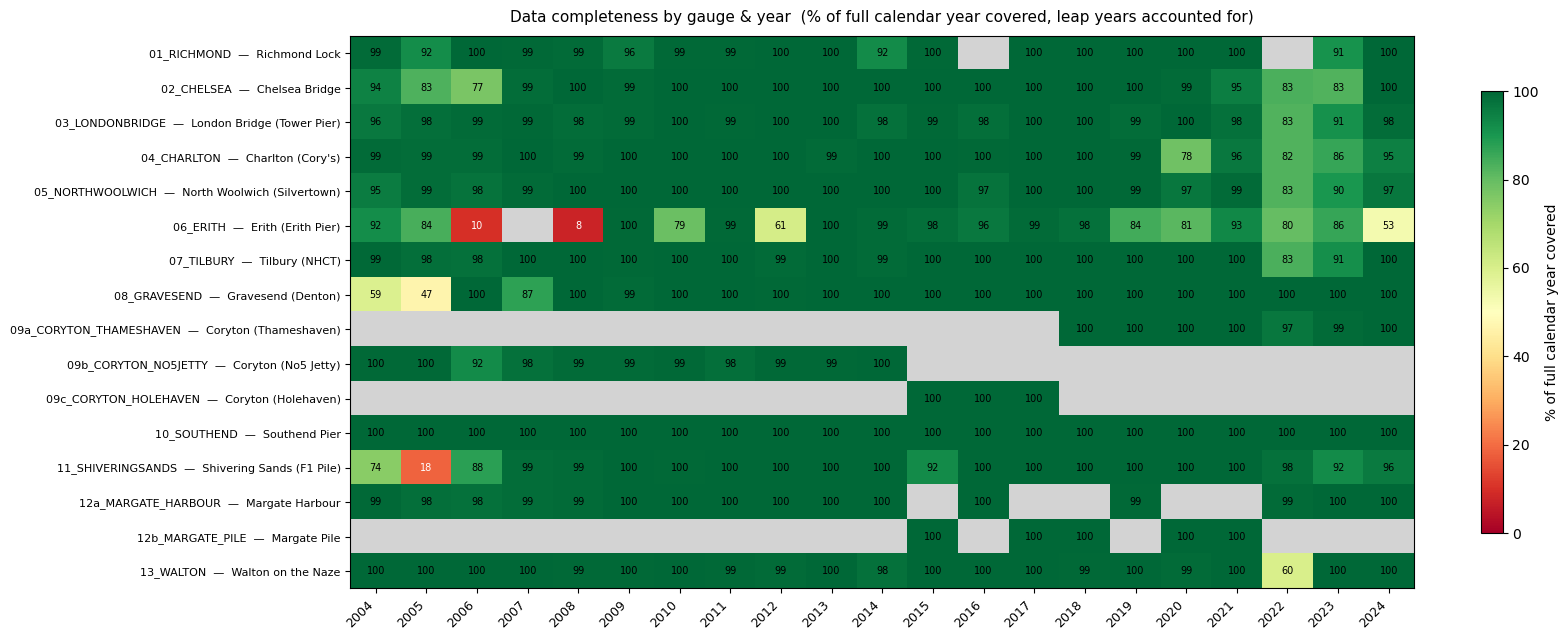

In [11]:
all_idsites = GAUGE_METADATA["idSite"].tolist()
years       = list(range(YEAR_START, YEAR_END + 1))
matrix      = np.full((len(all_idsites), len(years)), np.nan)

for i, idsite in enumerate(all_idsites):
    df = all_gauges.get(idsite)
    if df is None or df.empty:
        continue
    res = detect_resolution_minutes(df)
    for j, yr in enumerate(years):
        yr_df = df[df.DateTime.dt.year == yr]
        if yr_df.empty:
            continue
        exp = expected_records_full_year(yr, res)
        matrix[i, j] = min(len(yr_df) / exp * 100, 100)

fig, ax = plt.subplots(figsize=(17, 6.5))
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgrey")   # grey = no data at all for that year
im = ax.imshow(np.ma.masked_invalid(matrix), aspect="auto",
               cmap=cmap, vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="% of full calendar year covered", shrink=0.8)

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(all_idsites)))
ax.set_yticklabels(
    [f"{ids}  —  {GAUGE_METADATA.loc[ids, 'SiteName']}" for ids in all_idsites],
    fontsize=8,
)

for i in range(len(all_idsites)):
    for j in range(len(years)):
        val = matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=7, color="black" if val > 35 else "white")

ax.set_title(
    "Data completeness by gauge & year  "
    "(% of full calendar year covered, leap years accounted for)",
    fontsize=11, pad=10
)
plt.tight_layout()
plt.savefig("coverage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Save outputs
One CSV per **idSite** (the primary-key time-series files), plus `00_gauge_metadata.csv` as a lookup table. Join on `idSite` in any downstream analysis to recover the location info.

```python
# Example downstream usage:
ts   = pd.read_csv('3_Cleaned/09a_CORYTON_THAMESHAVEN.csv', parse_dates=['DateTime'])
meta = pd.read_csv('3_Cleaned/00_gauge_metadata.csv')
full = ts.merge(meta, on='idSite', how='left', suffixes=('', '_meta'))
```

In [12]:
OUTPUT_DIR = BASE_DIR.parent / "3_Cleaned"
OUTPUT_DIR.mkdir(exist_ok=True)

# 1) Per-gauge time-series CSVs, named by idSite.
print("Saving per-gauge time series...\n")
for idsite, df in all_gauges.items():
    out_path = OUTPUT_DIR / f"{idsite}.csv"
    df.to_csv(out_path, index=False)
    print(f"  Saved: {out_path.name:40s} ({len(df):>10,} rows)")

# 2) The metadata lookup table (location info, joinable on idSite).
meta_path = OUTPUT_DIR / "00_gauge_metadata.csv"
GAUGE_METADATA.to_csv(meta_path, index=False)
print(f"\n  Saved metadata: {meta_path.name}  ({len(GAUGE_METADATA)} gauges)")

print("\nAll clean files saved.")

Saving per-gauge time series...

  Saved: 01_RICHMOND.csv                          ( 1,076,814 rows)
  Saved: 02_CHELSEA.csv                           ( 1,057,679 rows)
  Saved: 03_LONDONBRIDGE.csv                      ( 1,080,316 rows)
  Saved: 04_CHARLTON.csv                          ( 1,067,937 rows)
  Saved: 05_NORTHWOOLWICH.csv                     ( 1,078,889 rows)
  Saved: 06_ERITH.csv                             (   841,766 rows)
  Saved: 07_TILBURY.csv                           ( 1,086,485 rows)
  Saved: 08_GRAVESEND.csv                         ( 1,046,626 rows)
  Saved: 09b_CORYTON_NO5JETTY.csv                 (   569,978 rows)
  Saved: 09c_CORYTON_HOLEHAVEN.csv                (   157,743 rows)
  Saved: 09a_CORYTON_THAMESHAVEN.csv              (   365,952 rows)
  Saved: 10_SOUTHEND.csv                          ( 1,103,956 rows)
  Saved: 11_SHIVERINGSANDS.csv                    ( 1,028,696 rows)
  Saved: 12a_MARGATE_HARBOUR.csv                  (   836,430 rows)
  Saved: 12b_MA